# DOTG: A simpler way to get logical error values

Borne out of a frustration that it shouldn't be difficult to run common experiments. 

DOTG wraps around stim to provide some different QEC code implementations,
as well as designing noise models for application to stim circuits.

Open source decoders are also implemented.

In [1]:
from dotg.decoders import MinimumWeightPerfectMatching
from dotg.circuits import SurfaceCode
from dotg.noise import DepolarizingNoise

In [ ]:
code = SurfaceCode.Rotated(distance=3, rounds=3)
circuit = code.memory
circuit

stim.Circuit('''
    QUBIT_COORDS(1, 1) 1
    QUBIT_COORDS(2, 0) 2
    QUBIT_COORDS(3, 1) 3
    QUBIT_COORDS(5, 1) 5
    QUBIT_COORDS(1, 3) 8
    QUBIT_COORDS(2, 2) 9
    QUBIT_COORDS(3, 3) 10
    QUBIT_COORDS(4, 2) 11
    QUBIT_COORDS(5, 3) 12
    QUBIT_COORDS(6, 2) 13
    QUBIT_COORDS(0, 4) 14
    QUBIT_COORDS(1, 5) 15
    QUBIT_COORDS(2, 4) 16
    QUBIT_COORDS(3, 5) 17
    QUBIT_COORDS(4, 4) 18
    QUBIT_COORDS(5, 5) 19
    QUBIT_COORDS(4, 6) 25
    R 1 3 5 8 10 12 15 17 19 2 9 11 13 14 16 18 25
    TICK
    H 2 11 16 25
    TICK
    CX 2 3 16 17 11 12 15 14 10 9 19 18
    TICK
    CX 2 1 16 15 11 10 8 14 3 9 12 18
    TICK
    CX 16 10 11 5 25 19 8 9 17 18 12 13
    TICK
    CX 16 8 11 3 25 17 1 9 10 18 5 13
    TICK
    H 2 11 16 25
    TICK
    MR 2 9 11 13 14 16 18 25
    DETECTOR(0, 4, 0) rec[-4]
    DETECTOR(2, 2, 0) rec[-7]
    DETECTOR(4, 4, 0) rec[-2]
    DETECTOR(6, 2, 0) rec[-5]
    TICK
    H 2 11 16 25
    TICK
    CX 2 3 16 17 11 12 15 14 10 9 19 18
    TICK
    CX 2 1

In [3]:
noise_model = DepolarizingNoise(1e-3)
noisy_circuit = noise_model.permute_circuit(circuit=circuit)
noisy_circuit

stim.Circuit('''
    QUBIT_COORDS(1, 1) 1
    QUBIT_COORDS(2, 0) 2
    QUBIT_COORDS(3, 1) 3
    QUBIT_COORDS(5, 1) 5
    QUBIT_COORDS(1, 3) 8
    QUBIT_COORDS(2, 2) 9
    QUBIT_COORDS(3, 3) 10
    QUBIT_COORDS(4, 2) 11
    QUBIT_COORDS(5, 3) 12
    QUBIT_COORDS(6, 2) 13
    QUBIT_COORDS(0, 4) 14
    QUBIT_COORDS(1, 5) 15
    QUBIT_COORDS(2, 4) 16
    QUBIT_COORDS(3, 5) 17
    QUBIT_COORDS(4, 4) 18
    QUBIT_COORDS(5, 5) 19
    QUBIT_COORDS(4, 6) 25
    R 1 3 5 8 10 12 15 17 19 2 9 11 13 14 16 18 25
    DEPOLARIZE1(0.0001) 1 3 5 8 10 12 15 17 19 2 9 11 13 14 16 18 25
    TICK
    H 2 11 16 25
    DEPOLARIZE1(0.0001) 2 11 16 25 1 3 5 8 9 10 12 13 14 15 17 18 19
    TICK
    CX 2 3 16 17 11 12 15 14 10 9 19 18
    DEPOLARIZE2(0.001) 2 3 16 17 11 12 15 14 10 9 19 18
    DEPOLARIZE1(0.0001) 1 5 8 13 25
    TICK
    CX 2 1 16 15 11 10 8 14 3 9 12 18
    DEPOLARIZE2(0.001) 2 1 16 15 11 10 8 14 3 9 12 18
    DEPOLARIZE1(0.0001) 5 13 17 19 25
    TICK
    CX 16 10 11 5 25 19 8 9 17 18 12 13
   

In [4]:
decoder = MinimumWeightPerfectMatching(circuit=noisy_circuit)
decoder.logical_error(num_shots=2e7)

0.000474

In [5]:
from dotg.decoders import BPOSD, LDPCDecoderOptions, OSDMethods

bposd_options = LDPCDecoderOptions(max_iterations=5, osd_method=OSDMethods.EXHAUSTIVE)
decoder = BPOSD(circuit=noisy_circuit, decoder_options=bposd_options)
decoder.logical_error(1e5)

0.00049

# Builder: Building circuits & lattice surgery experiments

Builder builds on top of stim, with different data structures to **abstract details away from the user**

In [21]:
from builder.utilities import QubitCoordinate

q = QubitCoordinate(100, 5)
q.idx

-1

You should never have to interact with a QubitCoordinate object.

In [ ]:
from builder.utilities.grids import SquareGrid

grid = SquareGrid(4, 4)

In [8]:
[q.idx for q in grid.z_stabilizers]

[15, 16, 17, 18, 19, 20]

You should never have to interact with a Grid object.

/var/folders/f1/t77prfc917gggkx3_k7348zw0000gn/T/ipykernel_86199/1197155480.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  code.draw().show()


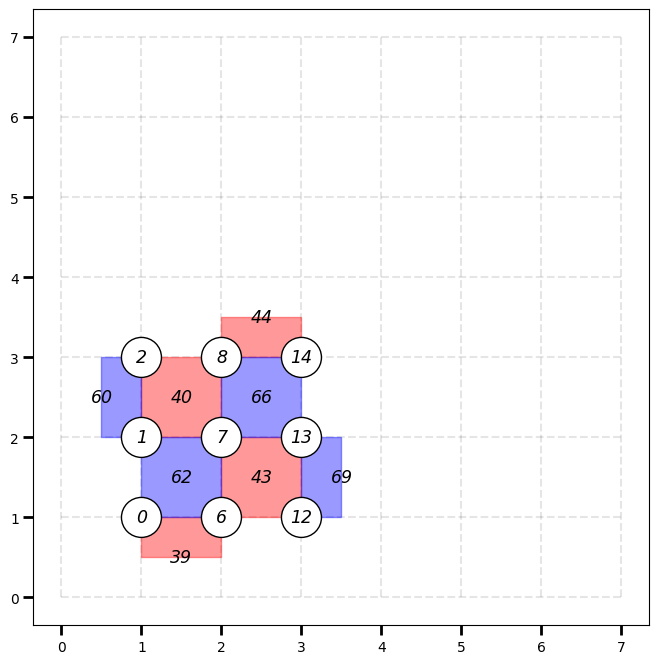

In [2]:
from builder.patches import RotatedSurfaceCode

grid = SquareGrid(7, 7)

code = RotatedSurfaceCode(code_distance=(3, 3), qubit_grid=grid, anchor=(1, 1))
code.draw().show()

You might want to directly interact with a Patch object.

More important is the LatticeSurgeryExperiment class, which controls stim circuits

In [ ]:
from builder.lattice_surgery import LatticeSurgeryExperiment

quantum_memory_experiment = LatticeSurgeryExperiment(qubit_grid=grid)

quantum_memory_experiment.reset_qubits(qubits=code.data_qubits, basis="RZ")
# quantum_memory_experiment.reset_qubits(qubits=code.x_stabilizers, basis="RX")
# quantum_memory_experiment.reset_qubits(qubits=code.z_stabilizers, basis="RZ")
# quantum_memory_experiment.tick()
# quantum_memory_experiment._depth_4_syndrome_extraction(patches=[code])
# quantum_memory_experiment.measure_qubits(qubits=code.x_stabilizers, basis="MX")
# quantum_memory_experiment.measure_qubits(qubits=code.z_stabilizers, basis="MZ")
# quantum_memory_experiment.detector_batch(
#     qubits=code.x_stabilizers, new_measurements_deterministic=False
# )
# quantum_memory_experiment.detector_batch(
#     qubits=code.z_stabilizers, new_measurements_deterministic=True
# )

In [46]:
quantum_memory_experiment.circuit

stim.Circuit('''
    QUBIT_COORDS(1, 1) 0
    QUBIT_COORDS(1, 2) 1
    QUBIT_COORDS(1, 3) 2
    QUBIT_COORDS(1, 4) 3
    QUBIT_COORDS(1, 5) 4
    QUBIT_COORDS(1, 6) 5
    QUBIT_COORDS(2, 1) 6
    QUBIT_COORDS(2, 2) 7
    QUBIT_COORDS(2, 3) 8
    QUBIT_COORDS(2, 4) 9
    QUBIT_COORDS(2, 5) 10
    QUBIT_COORDS(2, 6) 11
    QUBIT_COORDS(3, 1) 12
    QUBIT_COORDS(3, 2) 13
    QUBIT_COORDS(3, 3) 14
    QUBIT_COORDS(3, 4) 15
    QUBIT_COORDS(3, 5) 16
    QUBIT_COORDS(3, 6) 17
    QUBIT_COORDS(4, 1) 18
    QUBIT_COORDS(4, 2) 19
    QUBIT_COORDS(4, 3) 20
    QUBIT_COORDS(4, 4) 21
    QUBIT_COORDS(4, 5) 22
    QUBIT_COORDS(4, 6) 23
    QUBIT_COORDS(5, 1) 24
    QUBIT_COORDS(5, 2) 25
    QUBIT_COORDS(5, 3) 26
    QUBIT_COORDS(5, 4) 27
    QUBIT_COORDS(5, 5) 28
    QUBIT_COORDS(5, 6) 29
    QUBIT_COORDS(6, 1) 30
    QUBIT_COORDS(6, 2) 31
    QUBIT_COORDS(6, 3) 32
    QUBIT_COORDS(6, 4) 33
    QUBIT_COORDS(6, 5) 34
    QUBIT_COORDS(6, 6) 35
    QUBIT_COORDS(0.5, 1.5) 36
    QUBIT_COORDS(0.5, 3.5) 

In [4]:
from builder.lattice_surgery import QuantumMemory

qmem = QuantumMemory(code_distance=(3, 3), num_qubits=3, bases="Z")
qmem.run_experiment(3)

stim.Circuit('''
    QUBIT_COORDS(1, 1) 0
    QUBIT_COORDS(1, 2) 1
    QUBIT_COORDS(1, 3) 2
    QUBIT_COORDS(2, 1) 3
    QUBIT_COORDS(2, 2) 4
    QUBIT_COORDS(2, 3) 5
    QUBIT_COORDS(3, 1) 6
    QUBIT_COORDS(3, 2) 7
    QUBIT_COORDS(3, 3) 8
    QUBIT_COORDS(4, 1) 9
    QUBIT_COORDS(4, 2) 10
    QUBIT_COORDS(4, 3) 11
    QUBIT_COORDS(5, 1) 12
    QUBIT_COORDS(5, 2) 13
    QUBIT_COORDS(5, 3) 14
    QUBIT_COORDS(6, 1) 15
    QUBIT_COORDS(6, 2) 16
    QUBIT_COORDS(6, 3) 17
    QUBIT_COORDS(7, 1) 18
    QUBIT_COORDS(7, 2) 19
    QUBIT_COORDS(7, 3) 20
    QUBIT_COORDS(8, 1) 21
    QUBIT_COORDS(8, 2) 22
    QUBIT_COORDS(8, 3) 23
    QUBIT_COORDS(9, 1) 24
    QUBIT_COORDS(9, 2) 25
    QUBIT_COORDS(9, 3) 26
    QUBIT_COORDS(10, 1) 27
    QUBIT_COORDS(10, 2) 28
    QUBIT_COORDS(10, 3) 29
    QUBIT_COORDS(11, 1) 30
    QUBIT_COORDS(11, 2) 31
    QUBIT_COORDS(11, 3) 32
    QUBIT_COORDS(12, 1) 33
    QUBIT_COORDS(12, 2) 34
    QUBIT_COORDS(12, 3) 35
    QUBIT_COORDS(0.5, 1.5) 36
    QUBIT_COORDS(1

/var/folders/f1/t77prfc917gggkx3_k7348zw0000gn/T/ipykernel_78964/2745804757.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  qmem.draw(indices=False).show()


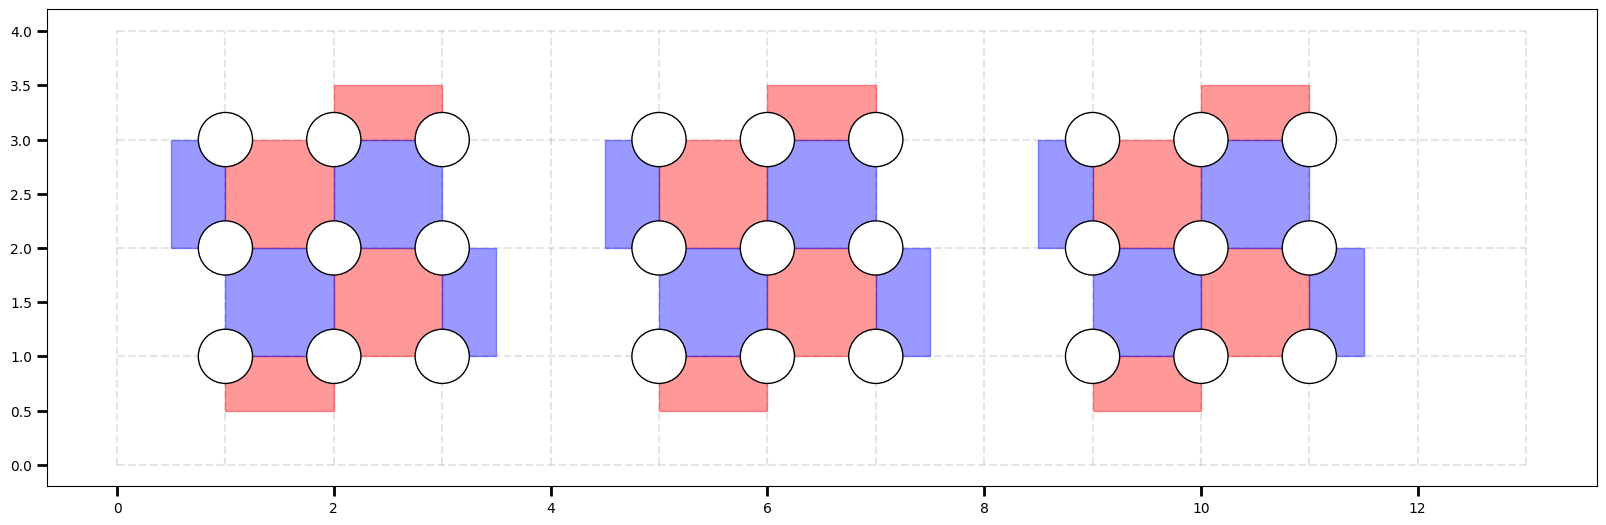

In [50]:
qmem.draw(indices=False).show()

In [5]:
from builder.lattice_surgery import CXExperiment

cx = CXExperiment(code_distance=7)
cx.run_experiment()

In [10]:
cx.circuit

stim.Circuit('''
    QUBIT_COORDS(1, 1) 0
    QUBIT_COORDS(1, 2) 1
    QUBIT_COORDS(1, 3) 2
    QUBIT_COORDS(1, 4) 3
    QUBIT_COORDS(1, 5) 4
    QUBIT_COORDS(1, 6) 5
    QUBIT_COORDS(1, 7) 6
    QUBIT_COORDS(1, 8) 7
    QUBIT_COORDS(1, 9) 8
    QUBIT_COORDS(1, 10) 9
    QUBIT_COORDS(1, 11) 10
    QUBIT_COORDS(1, 12) 11
    QUBIT_COORDS(1, 13) 12
    QUBIT_COORDS(1, 14) 13
    QUBIT_COORDS(1, 15) 14
    QUBIT_COORDS(2, 1) 15
    QUBIT_COORDS(2, 2) 16
    QUBIT_COORDS(2, 3) 17
    QUBIT_COORDS(2, 4) 18
    QUBIT_COORDS(2, 5) 19
    QUBIT_COORDS(2, 6) 20
    QUBIT_COORDS(2, 7) 21
    QUBIT_COORDS(2, 8) 22
    QUBIT_COORDS(2, 9) 23
    QUBIT_COORDS(2, 10) 24
    QUBIT_COORDS(2, 11) 25
    QUBIT_COORDS(2, 12) 26
    QUBIT_COORDS(2, 13) 27
    QUBIT_COORDS(2, 14) 28
    QUBIT_COORDS(2, 15) 29
    QUBIT_COORDS(3, 1) 30
    QUBIT_COORDS(3, 2) 31
    QUBIT_COORDS(3, 3) 32
    QUBIT_COORDS(3, 4) 33
    QUBIT_COORDS(3, 5) 34
    QUBIT_COORDS(3, 6) 35
    QUBIT_COORDS(3, 7) 36
    QUBIT_COORDS(3,

## Philosophy

Things that feel like they should be easy, should be easy. 

If something feels difficult to use, or feels unintuitive, it leaves a negative impression